In [1]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum

yu.setpath('analysis_gluon_stout')

enss=['b','c','d','e']
stouts=[5,7,10,13,15,20,25,30]

ens2Njk={'b':725,'c':400,'d':493,'e':516}

In [2]:
path='data_aux/RCs_np.pkl'
with open(path,'rb') as f:
    ens2RCs_np_me=pickle.load(f)
ens2RCs_np={ens:{} for ens in enss}
for ens in enss:
    for key in ens2RCs_np_me[ens]:
        if key.endswith('err'):
            continue
        ens2RCs_np[ens][key]=yu.jackknife_pseudo(ens2RCs_np_me[ens][key],ens2RCs_np_me[ens][f'{key}_err']*1+1e-10,ens2Njk[ens])[:,0]

In [30]:
ttej_key2bare_A20at0=yu.load_pkl_reg('ttej_key2bare_A20at0',pathlabel='analysis_A20')
key2bare_A20={key[2:]:val for key,val in ttej_key2bare_A20at0.items() if key[:2]==(0.8,0.3)}
yum.extendBare_avgx(key2bare_A20)
key2phy_A20=yum.bareRC2phy_avgx_np(key2bare_A20,ens2RCs_np,supjackQ=True)

In [4]:
fig,axs=yu.getFigAxs(1,2,sharex=True)
ax=axs[0,0]
for ist,stout in enumerate(stouts):
    for iens,ens in enumerate(enss):
        t=key2phy_A20[(ens,f'jg;stout{stout}')]
        mean,err=yu.jackme(t)
        
        plt_x=yu.ens2a[ens]**2+0.001/20*ist; plt_y=mean; plt_yerr=err
        ax.errorbar(plt_x,plt_y,plt_yerr,color=yu.colors8[ist],label=stout if iens==0 else None)
ax.set_xlim([0,0.008])
ax.legend(ncols=3)
        
ax=axs[0,1]
st_base=10
for ist,stout in enumerate(stouts):
    for iens,ens in enumerate(enss):
        t=key2phy_A20[(ens,f'jg;stout{stout}')]-key2phy_A20[(ens,f'jg;stout{st_base}')]
        mean,err=yu.jackme(t)
        
        plt_x=yu.ens2a[ens]**2+0.001/20*ist; plt_y=mean; plt_yerr=err
        ax.errorbar(plt_x,plt_y,plt_yerr,color=yu.colors8[ist],label=stout if iens==0 else None)

yu.finalizePlot('jg_jg-jg10')

0.303(68) 0.6186304653804257 14


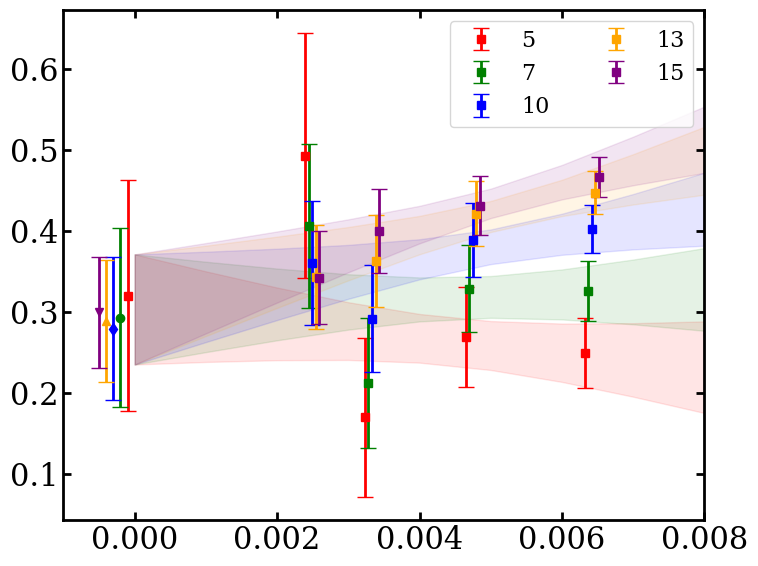

In [33]:
stouts=[5,7,10,13,15,20,25,30]
# stouts=[10,20,30]
stouts=[5,7,10,13,15]
y_jk=yu.superjackknife([np.transpose([key2phy_A20[(ens,f'jg;stout{stout}')] for stout in stouts]) for ens in enss])
def fitfunc(pars):
    return [pars[0]+pars[1+ist]*yu.ens2a[ens]**2 for ens in enss for ist,stout in enumerate(stouts)]
pars_jk,chi2_jk,Ndof,Nwarning=yu.jackfit(fitfunc,y_jk,pars0=[0.4]+[0]*len(stouts))
print(yu.jackme_un2str(pars_jk[:,0]),np.mean(chi2_jk)/Ndof,Ndof)

fig,axs=yu.getFigAxs(1,1,sharex=True)
ax=axs[0,0]
for ist,stout in enumerate(stouts):
    color=yu.colors8[ist]; fmt=yu.fmts8[ist]
    x=yum.lat_a2s_plt
    t=np.array([pars[0]+pars[1+ist]*x for pars in pars_jk])
    mean,err=yu.jackme(t)
    x=yum.lat_a2s_plt; ymin=mean-err; ymax=mean+err
    # ax.plot(x,mean,color=color,linestyle='--',marker='')
    ax.fill_between(x, ymin, ymax, color=color, alpha=0.1)
    
    for iens,ens in enumerate(enss):
        t=key2phy_A20[(ens,f'jg;stout{stout}')]
        mean,err=yu.jackme(t)
        plt_x=yu.ens2a[ens]**2+0.001/20*ist; plt_y=mean; plt_yerr=err
        ax.errorbar(plt_x,plt_y,plt_yerr,color=color,label=stout if iens==0 else None)
        
    t=key2phy_A20[('a=#_linear',f'jg;stout{stout}')][:,0]
    mean,err=yu.jackme(t)
    plt_x=-0.001/10*(ist+1); plt_y=mean; plt_yerr=err
    ax.errorbar(plt_x,plt_y,plt_yerr,color=color,fmt=fmt)
        
ax.set_xlim([-0.001,0.008])
ax.legend(ncols=2)

yu.finalizePlot('jointLinear',closeQ=False)

# rainbow check stout dep

In [6]:
# projs=['P0', 'Px', 'Py', 'Pz']
# inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']
# enss=['b','c','d','e']

# ens2c2pt={}; ens2moms_2pt={}; ens2c2pt0={}; ens2Njk={}
# for ens in enss:
#     if ens in ['e']:
#         basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
#         path=f'{basepath}disc_2pt_N=100,127,84_sup.h5'
#         with h5py.File(path) as f:
#             moms_2pt=yu.moms2list(f['moms'])
#             c2pt=yu.jackknife(np.real(f['data/N_N'][:,:,:]))
#             c2pt=yu.superjackknife(c2pt,yum.key2cfgs[(ens,'N')],yum.key2cfgs[(ens,'all')])
#     else:
#         basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
#         path=f'{basepath}disc_2pt.h5'
#         with h5py.File(path) as f:
#             moms_2pt=yu.moms2list(f['moms'])
#             c2pt=yu.jackknife(np.real(f['data/N_N'][:,:,:]))
        
#     ens2moms_2pt[ens]=moms_2pt
#     ens2c2pt[ens]=c2pt
#     ens2c2pt0[ens]=c2pt[:,:,moms_2pt.index([0,0,0])]
#     ens2Njk[ens]=len(c2pt)

# key2tf2ratio={}
# stouts=[5,7,10,13,15,20,25,30,35,40]
# # stouts=range(0,41)
# js=['j+;disc','js;disc','jc;disc']+[f'jg;stout{stout}' for stout in stouts]
# for ens in enss:
#     if ens in ['e']:
#         path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DV/{yu.ens2full[ens]}/data_merge_sup/disc_0,0,1,0,0,0.h5'
#         with h5py.File(path) as f:
#             for jtf in f['data'].keys():
#                 j,tf=jtf.split('_'); tf=int(tf)
#                 if j not in js:
#                     continue        
#                 key=(ens,j)
#                 if key not in key2tf2ratio:
#                     key2tf2ratio[key]={}
#                 c3pt=yu.jackknife(f['data'][jtf][:,:,0,projs.index('P0'),inserts.index('tz')])
#                 c3pt=yu.superjackknife(c3pt,yum.key2cfgs[(ens,yum.j2jkey(j))],yum.key2cfgs[(ens,'all')])
#                 c2pt=ens2c2pt[ens][:,tf,ens2moms_2pt[ens].index([0,0,1])]
#                 factor=1/(1j*2*np.pi/yu.ens2NL[ens])
#                 ratio=np.real(c3pt/c2pt[:,None]*factor)
#                 key2tf2ratio[key][tf]=ratio
#     else:
#         path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DV/{yu.ens2full[ens]}/data_merge/disc_0,0,1,0,0,0.h5'
#         with h5py.File(path) as f:
#             for jtf in f['data'].keys():
#                 j,tf=jtf.split('_'); tf=int(tf)
#                 if j not in js:
#                     continue        
#                 key=(ens,j)
#                 if key not in key2tf2ratio:
#                     key2tf2ratio[key]={}
#                 c3pt=yu.jackknife(f['data'][jtf][:,:,0,projs.index('P0'),inserts.index('tz')])
#                 c2pt=ens2c2pt[ens][:,tf,ens2moms_2pt[ens].index([0,0,1])]
#                 factor=1/(1j*2*np.pi/yu.ens2NL[ens])
#                 ratio=np.real(c3pt/c2pt[:,None]*factor)
#                 key2tf2ratio[key][tf]=ratio
            
# ens2tfs_disc={}
# for ens in enss:
#     tfs=list(key2tf2ratio[(ens,'j+;disc')].keys()); tfs.sort()
#     ens2tfs_disc[ens]=tfs
#     print(ens,tfs[0],tfs[-1])

In [7]:
# t=[
#     {tf:key2tf2ratio[(ens,'jg;stout40')][tf]*ens2RCs_np[ens]['Zgg^40(mu!=nu)'][:,None]-\
#         key2tf2ratio[(ens,'jg;stout7')][tf]*ens2RCs_np[ens]['Zgg^7(mu!=nu)'][:,None] for tf in [2,4,6,8,10,12,14,16,18,20]}
#     for ens in enss]

# fig,axs=yu.makePlot_3pt_rainbow(t,sharey=True)
# for i in range(4):
#     yu.addRefLine(axs[i,0],0)
#     yu.addRefLine(axs[i,1],0)
# yu.finalizePlot(closeQ=True)